# **Evaluación 3: Carseats**

SCY1101 Programación para la Ciencia de Datos.

### **Integrantes**

**Estudiante 1:** Benjamín Marchant Silva.

**Estudiante 2:** Benjamín Sánchez Vega.

**Sección:** 002D.

# **Caso de estudio.**

Para realizar la evaluación se debe utilizar el dataset ***carseats.csv***, que corresponde a una agrupación de datos que describen ventas de sillas para niños, características de las tiendas y comunidades donde se venden.

Los datos que conforman el dataset son los siguientes:

*   `Sales`: Ventas de sillas (en miles de unidades) en cada teinda.  
*   `CompPrice`: Precio que cobra el competidor en esa ubicación.            
*   `Income`: Nivel de ingreso de la comunidad (en miles de dólares).               
*   `Advertising`: Presupuesto local de publicidad de la empresa (en miles de dólares).                  
*   `Population`: Tamaño de la población de la región (en miles).
*   `Price`: Precio que cobra la empresa por las sillas en esa tienda.
*   `ShelveLoc`: Calidad de la ubicación en la estantería (factor con niveles: Bad, Medium, Good).
*   `Age`: Edad promedio de la población local.
*   `Education`: Nivel educativo promedio en la comunidad.
*   `Urban`: Factor binario (Yes/No) que indica si la tienda está en zona urbana.
*   `US`: Factor binario (Yes/No) que indica si la tienda está en EE.UU. o no.

Ademas, se requiere crear una nueva variable booleana llamada `HighSales` que indique si las ventas de una tienda son altas (1) o bajas (0). Para ello, considere como ventas altas aquellas superiores a 8.

Mientras que por otra indicación, se solicita estandarizar la informaciónn, en este caso, convertir las columnas con valores monetarios expresados en **dólares estadounidensesconvierta** a **pesos chilenos (CLP)** utilizando una de las API de tipo de cambio entregada.



Inicialización de los datos.

In [ ]:
#. Importación de librerias a utilizar.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests
from sklearn.model_selection import GridSearchCV
import plotly.express as px
from plotly.offline import iplot
import threading
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, silhouette_score)

from mpl_toolkits.mplot3d import Axes3D

import sys
!{sys.executable} -m pip install dash dash_bootstrap_components --quiet
import dash
from dash import Dash, html, dcc, Input, Output
import dash_bootstrap_components as dbc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 12.0 MB/s eta 0:00:00


In [ ]:
#. Lectura del dataset.
df = pd.read_csv('dataset_car_seats.csv')

# **Optimización del DataFrame.**

En esta etapa se llevará a cabo la optimización del DataFrame, con el objetivo de integrar una nueva columna, modificar ciertas variables previamente indicadas y preparar la información para análisis posteriores.

Para ello, en primer lugar, se generará una copia del conjunto de datos original, sobre la cual se realizarán todas las transformaciones, evitando así modificaciones directas sobre los datos iniciales.

In [ ]:
#. Creación del DataFrame en base al original.
df_mod = df.copy()
df_mod.head()

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


## **Integración de `HighSales`.**

Se integrará una nueva columna llamada `HighSales` que almacena el resultado de una condición establecida de una columna previamente existente, con el fin de optimizar los datos. Además, esta almacenará la información de que si las ventas de una tienda son **altas (1)** o **bajas (0)**, considerando como ventas altas aquellas **superiores a 8**.

In [ ]:
#. Integración de la columna.
df_mod["HighSales"] = (df_mod["Sales"] > 8).astype(int)
df_mod.head()

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,HighSales
0,0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1
1,1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,1
2,2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,1
3,3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,0
4,4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,0


## **Conversión de valores.**

Se desarrollará la estandarización de la información monetaria, transformando las columnas expresadas en **dólares estadounidenses** a **pesos chilenos (CLP)**, utilizando para ello una API de tipo de cambio.

In [ ]:
#. Llamado de la API.
url = 'https://cl.dolarapi.com/v1/cotizaciones/usd'
r = requests.get(url)
r.json()

{'moneda': 'USD',
 'nombre': 'Dólar',
 'compra': 920,
 'venta': 922,
 'ultimoCierre': 918.61,
 'fechaActualizacion': '2026-06-25T20:01:34.583Z'}

In [ ]:
#. Identificación del cambio.
tipo_cambio = r.json()["venta"]
print("Tipo de cambio:", tipo_cambio)

Tipo de cambio: 922


In [ ]:
#. Identificación de columnas a convertir.
columnas_usd = ["CompPrice", "Income", "Advertising", "Price"]

#. Conversión de valores.
for col in columnas_usd:
    df_mod[col] = (df_mod[col] * tipo_cambio).round(0)

df_mod.head()

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,HighSales
0,0,9.50,127236,67306,10142,276,110640,Bad,42,17,Yes,Yes,1
1,1,11.22,102342,44256,14752,260,76526,Good,65,10,Yes,Yes,1
2,2,10.06,104186,32270,9220,269,73760,Medium,59,12,Yes,Yes,1
3,3,7.40,107874,92200,3688,466,89434,Medium,55,14,Yes,Yes,0
4,4,4.15,130002,59008,2766,340,118016,Bad,38,13,Yes,No,0


Ya una vez realizada la optimización del DataFrame, donde se integra una nueva columna y se convierten los valores, se puede continuar con el análisis de este.

# **Análisis exploratorio de datos.**

In [ ]:
#. Vista general del dataset.
df_mod.head()

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,HighSales
0,0,9.50,127236,67306,10142,276,110640,Bad,42,17,Yes,Yes,1
1,1,11.22,102342,44256,14752,260,76526,Good,65,10,Yes,Yes,1
2,2,10.06,104186,32270,9220,269,73760,Medium,59,12,Yes,Yes,1
3,3,7.40,107874,92200,3688,466,89434,Medium,55,14,Yes,Yes,0
4,4,4.15,130002,59008,2766,340,118016,Bad,38,13,Yes,No,0


In [ ]:
#. Información general del dataset.
df_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   400 non-null    int64  
 1   Sales        400 non-null    float64
 2   CompPrice    400 non-null    int64  
 3   Income       400 non-null    int64  
 4   Advertising  400 non-null    int64  
 5   Population   400 non-null    int64  
 6   Price        400 non-null    int64  
 7   ShelveLoc    400 non-null    object 
 8   Age          400 non-null    int64  
 9   Education    400 non-null    int64  
 10  Urban        400 non-null    object 
 11  US           400 non-null    object 
 12  HighSales    400 non-null    int64  
dtypes: float64(1), int64(9), object(3)
memory usage: 40.8+ KB


In [ ]:
#. Visualización de estdísticas descriptivas de los datos.
df_mod.describe()

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education,HighSales
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,199.500000,7.496325,115226.950000,63302.215000,6117.470000,264.840000,106762.990000,53.322500,13.900000,0.410000
std,115.614301,2.824115,14138.419608,25803.125659,6131.635748,147.376436,21829.884557,16.200297,2.620528,0.492449
min,0.000000,0.000000,70994.000000,19362.000000,0.000000,10.000000,22128.000000,25.000000,10.000000,0.000000
25%,99.750000,5.390000,106030.000000,39415.500000,0.000000,139.000000,92200.000000,39.750000,12.000000,0.000000
50%,199.500000,7.490000,115250.000000,63618.000000,4610.000000,272.000000,107874.000000,54.500000,14.000000,0.000000
75%,299.250000,9.320000,124470.000000,83902.000000,11064.000000,398.500000,120782.000000,66.000000,16.000000,1.000000
max,399.000000,16.270000,161350.000000,110640.000000,26738.000000,509.000000,176102.000000,80.000000,18.000000,1.000000


In [ ]:
#. Verificación de valores nulos.
df_mod.isnull().sum()

,0
Unnamed: 0,0
Sales,0
CompPrice,0
Income,0
Advertising,0
Population,0
Price,0
ShelveLoc,0
Age,0
Education,0


In [ ]:
#. Verificación de registros duplicados.
duplicate_rows = df_mod[df_mod.duplicated()]
display(duplicate_rows)

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,HighSales


In [ ]:
#. Almacenamiento de columnas por clasificación.
num_cols = df_mod.select_dtypes(include=['number']).columns.tolist()
cat_cols = df_mod.select_dtypes(include=['object', 'category']).columns.tolist()
print("Columnas Numéricas:", num_cols)
print("Columnas Categóricas:", cat_cols)

Columnas Numéricas: ['Unnamed: 0', 'Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'Age', 'Education', 'HighSales']
Columnas Categóricas: ['ShelveLoc', 'Urban', 'US']


In [ ]:
#. Identificación de Outliers a través de los gráficos 'Box-Plot' (variables numericas).
for col in num_cols:

    fig = px.box(
        df_mod,
        x = col,
        title = f'Gráfico de la columna {col}.'
    )

    fig.show()

In [ ]:
#. Identificación de registros a través de los gráficos 'Count-Plot' (variables categoricas).
for col in cat_cols:

    conteos = df_mod[col].value_counts().reset_index()
    conteos.columns = [col, 'Conteo']

    fig = px.bar(
        conteos,
        x = col,
        y = 'Conteo',
        title = f'Distribución de la Columna {col}.'
    )

    fig.update_layout(
        xaxis_title=col,
        yaxis_title = 'Conteo'
    )

    fig.update_xaxes(tickangle = 45)

    fig.show()

In [ ]:
#. Identificación de la correlación mantenidas entre las columnas.
corr_matrix = df_mod.corr(numeric_only=True)

fig = px.imshow(
    corr_matrix,
    text_auto = True,
    color_continuous_scale = 'RdBu_r',
    aspect = 'auto'
)

fig.update_layout(
    title = 'Matriz de Correlación'
)

fig.show()

Con el análsis ya realizado se puede concluir que:

* No se encuentran registros con valores nulos.
* No se encuentran registros con valores duplicados.
* No se presentan outliers.
* No se presentan registro de valores mal integrados.

Gracias este análisis, se puede proceder a la construcción del Dashboard, donde se construirán gráficos relacionados al DataFrame.

# **Dashboard.**

## **Gráficos.**

### **`Population` VS `Sales`.**

In [ ]:
#. Configuración del gráfico.
fig_population = px.scatter(
    df_mod,
    x="Population",
    y="Sales",
    color="HighSales",
    trendline="ols",
    title="Relación entre Población y Ventas"
)

fig_population.show()

De acuerdo con el gráfico de dispersión, que compara las variables 'Population' y 'Sales', no se observa una relación clara entre el tamaño de la población y el nivel de ventas. Se pueden encontrar tiendas ubicadas en zonas con baja población que presentan ventas elevadas, así como tiendas en zonas con alta población que registran ventas bajas. Esto sugiere que la población no es un factor determinante por sí sola para explicar el comportamiento de las ventas en las tiendas analizadas.

### **`ShelveLoc` VS `HighSales`.**


In [ ]:
df_temp = df_mod.copy()

df_temp["HighSales"] = df_temp["HighSales"].map({
    0: "Ventas Bajas",
    1: "Ventas Altas"
})

#. Configuración del gráfico.
fig_shelve = px.histogram(
    df_temp,
    x="ShelveLoc",
    color="HighSales",
    barmode="group",
    title="Ventas Altas y Bajas según ubicación de Estantería"
)

fig_shelve.show()

El gráfico de barras agrupadas muestra la relación entre la ubicación en estantería (ShelveLoc) y la variable objetivo HighSales, diferenciando entre ventas altas y bajas. Se observa que la categoría Medium concentra una mayor cantidad total de registros, predominando las ventas bajas sobre las altas. En cambio, la categoría Good presenta una menor cantidad de registros, pero con una mayor proporción de ventas altas en comparación con ventas bajas. Por su parte, la categoría Bad tiende a asociarse principalmente con ventas bajas. En conjunto, estos resultados sugieren que una mejor ubicación en estantería se asocia con una mayor probabilidad de obtener ventas altas, aunque la distribución de los datos no es uniforme entre categorías.

### **`HighSales`.**

In [ ]:
highsales_count = df_mod["HighSales"].value_counts().reset_index()
highsales_count.columns = ["HighSales", "Cantidad"]

highsales_count["HighSales"] = highsales_count["HighSales"].map({
    0: "Ventas Bajas",
    1: "Ventas Altas"
})

#. Configuración del gráfico.
fig_highsales = px.pie(
    highsales_count,
    names="HighSales",
    values="Cantidad",
    title="Distribución de Ventas Altas y Bajas"
)

fig_highsales.update_traces(
    pull=[0.05, 0.05],
    textinfo="percent+label",
    textfont_size=14
)

fig_highsales.show()

El gráfico de torta presenta la distribución de la variable objetivo 'HighSales', mostrando la proporción de
tiendas con ventas altas y bajas.

### **`ShelveLoc` VS `Sales`.**

In [ ]:
#. Configuración del gráfico.
fig_shelve_sales = px.box(
    df_mod,
    x="ShelveLoc",
    y="Sales",
    color="ShelveLoc",
    title="Impacto de la ubicación en estantería"
)

fig_shelve_sales.show()

## **Construcción del Dashboard.**

### **Configuración de Ngrok.**

In [ ]:
# Instalar pyngrok, la librería de Python para ngrok
!pip install pyngrok --quiet

# Descargar ngrok (si no está disponible en el entorno de Colab)
!wget https://bin.equinox.io/c/4VmDzA7iaHb/ngrok-stable-linux-amd64.zip --no-check-certificate
!unzip ngrok-stable-linux-amd64.zip

# Asegurarse de que el ejecutable ngrok esté en el path o sea accesible
import os
if not os.path.exists('./ngrok'):
  print("ADVERTENCIA: 'ngrok' no encontrado en el directorio actual. Asegúrese de que la descarga y descompresión fueron exitosas.")

--2026-06-25 23:57:20--  https://bin.equinox.io/c/4VmDzA7iaHb/ngrok-stable-linux-amd64.zip
Resolving bin.equinox.io (bin.equinox.io)... 13.248.244.96, 35.71.179.82, 99.83.220.108, ...
Connecting to bin.equinox.io (bin.equinox.io)|13.248.244.96|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13921656 (13M) [application/octet-stream]
Saving to: ‘ngrok-stable-linux-amd64.zip’

ngrok-stable-linux- 100%[===================>]  13.28M  29.0MB/s    in 0.5s    

2026-06-25 23:57:21 (29.0 MB/s) - ‘ngrok-stable-linux-amd64.zip’ saved [13921656/13921656]

Archive:  ngrok-stable-linux-amd64.zip
  inflating: ngrok                   


In [ ]:
from pyngrok import ngrok
from google.colab import userdata

# Para Colab, es mejor usar `userdata.get` para tu token.
# Asegúrate de haber guardado tu authtoken de ngrok en los 'Secrets' de Colab bajo el nombre 'NGROK_AUTH_TOKEN'

NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
if NGROK_AUTH_TOKEN:
  ngrok.set_auth_token(NGROK_AUTH_TOKEN)
  print("ngrok authtoken configurado.")
else:
  print("ADVERTENCIA: ngrok authtoken no encontrado en Secrets. El túnel podría fallar o tener limitaciones.")

ngrok authtoken configurado.


In [ ]:
# Inicializar la aplicación Dash
app = dash.Dash(__name__)

# Definir el layout del dashboard
app.layout = html.Div(children=[
    html.H1("Dashboard Carseats - Análisis de Ventas", className="text-center mb-4"),

    dbc.Row([
        dbc.Col(dcc.Graph(figure=fig_population), width=6),
        dbc.Col(dcc.Graph(figure=fig_shelve), width=6),
    ]),

    dbc.Row([
        dbc.Col(dcc.Graph(figure=fig_shelve_sales), width=6),
        dbc.Col(dcc.Graph(figure=fig_highsales), width=6),
    ]),

])

# Función para iniciar el servidor Dash en un hilo separado
def run_dash_app():
    app.run(debug=False, port=8051)

# Iniciar el servidor Dash en un hilo separado
dash_thread = threading.Thread(target=run_dash_app)
dash_thread.start()

print("La aplicación Dash se está ejecutando en segundo plano en el puerto 8051.")

Dash is running on http://127.0.0.1:8051/

La aplicación Dash se está ejecutando en segundo plano en el puerto 8051.


INFO:dash.dash:Dash is running on http://127.0.0.1:8051/



In [ ]:
# Abre un túnel HTTP en el puerto 8051
public_url = ngrok.connect(8051)
print(f"El dashboard de Dash es accesible a través de esta URL: {public_url}")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8051
INFO:werkzeug:Press CTRL+C to quit


El dashboard de Dash es accesible a través de esta URL: NgrokTunnel: "https://unstirred-roulette-blank.ngrok-free.dev" -> "http://localhost:8051"


# **Modelos supervisados.**

Ya completado el análisis, se desarrollaran 3 modelos supervisados distintos, con el fin de clasificar ***Carseats*** como:

*   Venta alta (superior a 8) / `HighSales = 1`
*   Venta baja (inferior a 8) / `HighSales = 0`

Para esto, se utilizarán las siguientes variables:

*   `CompPrice`        
*   `Income`             
*   `Advertising`             
*   `Population`
*   `Price`
*   `ShelveLoc`
*   `Age`
*   `Education`
*   `Urban`
*   `US`

Los modelos a utilizar permitarán análizar la capacidad de predecir, estableciendo cual es el modelo con mejor desempeño. Lo que se busca con el desarrollo de los modelos es el siguiente:

*   Entrenarlos.
*   Evaluar su rendimiento.
*   Optimizar los hiperparámetros.
*   Comparar resultados.
*   Identificar el mejor modelo.

> Los modelos a implementar, con su respectivo método de optimización, son los siguientes:

| Modelo                   | Método de optimización |
| ------------------------ | ---------------------- |
| `K-Nearest Neighbors`    | `GridSearchCV`         |
| `Decision Tree`          | `GridSearchCV`         |
| `Logistic Regression`    | `GridSearchCV`         |

Antes del entrenamiento de los modelos se establecera:

*   La selección de variables predictoras.
*   La selección de la variable objetivo.
*   La división de los datos.
*   Escalamiento de variables.

## **Preparación de los datos.**

In [ ]:
df_modSup = df_mod.copy()
df_modSup.head()

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,HighSales
0,0,9.50,127236,67306,10142,276,110640,Bad,42,17,Yes,Yes,1
1,1,11.22,102342,44256,14752,260,76526,Good,65,10,Yes,Yes,1
2,2,10.06,104186,32270,9220,269,73760,Medium,59,12,Yes,Yes,1
3,3,7.40,107874,92200,3688,466,89434,Medium,55,14,Yes,Yes,0
4,4,4.15,130002,59008,2766,340,118016,Bad,38,13,Yes,No,0


In [ ]:
df_modSup.drop(columns=['Unnamed: 0'], inplace=True)

df_modSup.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,HighSales
0,9.50,127236,67306,10142,276,110640,Bad,42,17,Yes,Yes,1
1,11.22,102342,44256,14752,260,76526,Good,65,10,Yes,Yes,1
2,10.06,104186,32270,9220,269,73760,Medium,59,12,Yes,Yes,1
3,7.40,107874,92200,3688,466,89434,Medium,55,14,Yes,Yes,0
4,4.15,130002,59008,2766,340,118016,Bad,38,13,Yes,No,0


In [ ]:
X = df_modSup.drop(columns=['Sales', 'HighSales'])

y = df_modSup['HighSales']

In [ ]:
print(X.columns)

Index(['CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')


In [ ]:
X.dtypes

,0
CompPrice,int64
Income,int64
Advertising,int64
Population,int64
Price,int64
ShelveLoc,object
Age,int64
Education,int64
Urban,object
US,object


In [ ]:
X = pd.get_dummies(
    X,
    columns=['ShelveLoc', 'Urban', 'US'],
    drop_first=True
)

In [ ]:
X.head()

,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_Good,ShelveLoc_Medium,Urban_Yes,US_Yes
0,127236,67306,10142,276,110640,42,17,False,False,True,True
1,102342,44256,14752,260,76526,65,10,True,False,True,True
2,104186,32270,9220,269,73760,59,12,False,True,True,True
3,107874,92200,3688,466,89434,55,14,False,True,True,True
4,130002,59008,2766,340,118016,38,13,False,False,True,False


In [ ]:
print(X.shape)

X.info()

(400, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   CompPrice         400 non-null    int64
 1   Income            400 non-null    int64
 2   Advertising       400 non-null    int64
 3   Population        400 non-null    int64
 4   Price             400 non-null    int64
 5   Age               400 non-null    int64
 6   Education         400 non-null    int64
 7   ShelveLoc_Good    400 non-null    bool 
 8   ShelveLoc_Medium  400 non-null    bool 
 9   Urban_Yes         400 non-null    bool 
 10  US_Yes            400 non-null    bool 
dtypes: bool(4), int64(7)
memory usage: 23.6 KB


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (320, 11)
Test: (80, 11)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
print("Variables predictoras finales:")

for col in X.columns:
    print(col)

Variables predictoras finales:
CompPrice
Income
Advertising
Population
Price
Age
Education
ShelveLoc_Good
ShelveLoc_Medium
Urban_Yes
US_Yes


## **Decision Tree.**

In [ ]:
#. Creación del modelo.
tree_model = DecisionTreeClassifier(random_state = 42)

#. Entrenamiento del modelo.
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
#. Predicciones sobre datos de prueba.
y_pred_tree = tree_model.predict(X_test)

#. Visualización de primeras predicciones.
print(y_pred_tree[:100])

[0 0 0 0 0 1 1 0 0 0 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1 0 0 0 0 1 1 1 1 1 0 1 0
 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1 1 0 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 1
 1 1 1 1 0 1]


In [ ]:
#. Cálculo de accuracy.
tree_accuracy = accuracy_score(y_test, y_pred_tree)

print(f'Accuracy del modelo: {tree_accuracy:.2f}')

Accuracy del modelo: 0.71


In [ ]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.76      0.74      0.75        47
           1       0.65      0.67      0.66        33

    accuracy                           0.71        80
   macro avg       0.70      0.71      0.70        80
weighted avg       0.71      0.71      0.71        80



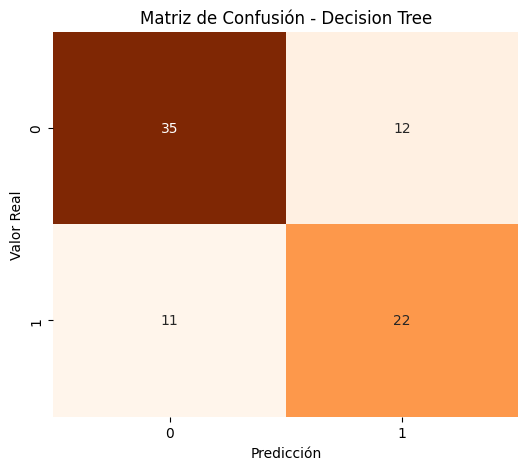

In [ ]:
#. Matriz de confusión.
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_tree,
    cbar = False,
    annot = True,
    fmt = 'd',
    cmap = 'Oranges'
)

plt.title('Matriz de Confusión - Decision Tree')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')

plt.show()

In [ ]:
#. Importancia de variables.
importance = tree_model.feature_importances_

#. Creación de DataFrame.
importance_df = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importance
})

#. Ordenar valores.
importance_df = importance_df.sort_values(
    by = 'Importancia',
    ascending = False
)

#. Visualización.
importance_df

,Variable,Importancia
4,Price,0.246073
7,ShelveLoc_Good,0.137601
0,CompPrice,0.126972
5,Age,0.113930
2,Advertising,0.104166
1,Income,0.095678
3,Population,0.051514
8,ShelveLoc_Medium,0.049853
6,Education,0.040017
9,Urban_Yes,0.018956


### **Optimización del modelo.**

In [ ]:
#. Modelo base.
tree_model = DecisionTreeClassifier(random_state = 42)

#. Hiperparámetros.
param_grid = {
  'criterion': ['gini', 'entropy'],
  'max_depth': [ 3, 5, 7, 10, 15, 20,],
  'min_samples_split': [2, 5, 10],
  'min_samples_leaf': [1, 2, 4]
}

#. GridSearchCV.
grid_tree = GridSearchCV(
    estimator = tree_model,
    param_grid = param_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)

#. Entrenamiento.
grid_tree.fit(X_train, y_train)

In [ ]:
#. Conversión de resultados.
grid_results = pd.DataFrame(grid_tree.cv_results_)

#. Columnas relevantes.
grid_results = grid_results[[
  'params',
  'mean_test_score',
  'rank_test_score'
]]

#. Ordenar resultados.
grid_results = grid_results.sort_values(by = 'rank_test_score')

grid_results.head(10)

,params,mean_test_score,rank_test_score
9,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.743750,1
36,"{'criterion': 'gini', 'max_depth': 15, 'min_sa...",0.743750,1
45,"{'criterion': 'gini', 'max_depth': 20, 'min_sa...",0.743750,1
10,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.740625,4
18,"{'criterion': 'gini', 'max_depth': 7, 'min_sam...",0.734375,5
19,"{'criterion': 'gini', 'max_depth': 7, 'min_sam...",0.731250,6
27,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",0.731250,6
21,"{'criterion': 'gini', 'max_depth': 7, 'min_sam...",0.728125,8
0,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.728125,8
1,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.728125,8


In [ ]:
print("Mejores parámetros encontrados:\n")
print(grid_tree.best_params_)
print(f'\nMejor accuracy promedio: ' f'{grid_tree.best_score_:.2f}')

Mejores parámetros encontrados:

{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

Mejor accuracy promedio: 0.74


In [ ]:
best_tree_model = grid_tree.best_estimator_

print(best_tree_model)

DecisionTreeClassifier(max_depth=5, random_state=42)


In [ ]:
y_pred_best_tree = best_tree_model.predict(X_test)

print("Primeras predicciones:")
print(y_pred_best_tree[:100])

Primeras predicciones:
[0 0 1 0 0 1 1 0 0 0 0 0 1 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0
 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 1 0 0 1 0 0 1
 1 1 1 0 0 0]


In [ ]:
best_tree_accuracy = accuracy_score(y_test, y_pred_best_tree)

print(f'Accuracy optimizado: ' f'{best_tree_accuracy:.2f}')

Accuracy optimizado: 0.78


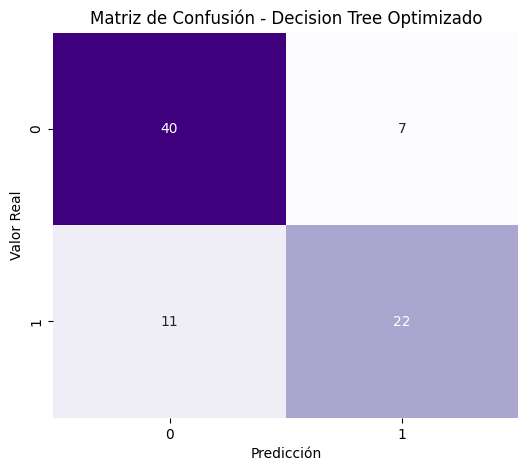

In [ ]:
#. Matriz de confusión.
cm_best_tree = confusion_matrix(y_test, y_pred_best_tree)

plt.figure(figsize = (6,5))

sns.heatmap(
    cm_best_tree,
    cbar = False,
    annot = True,
    fmt = 'd',
    cmap = 'Purples'
)

plt.title('Matriz de Confusión - Decision Tree Optimizado')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')

plt.show()

In [ ]:
print(classification_report(y_test, y_pred_best_tree))

              precision    recall  f1-score   support

           0       0.78      0.85      0.82        47
           1       0.76      0.67      0.71        33

    accuracy                           0.78        80
   macro avg       0.77      0.76      0.76        80
weighted avg       0.77      0.78      0.77        80



In [ ]:
#. Importancia.
best_importance = best_tree_model.feature_importances_

#. DataFrame.
best_importance_df = pd.DataFrame({

    'Variable': X.columns,

    'Importancia': best_importance
})

#. Ordenar.
best_importance_df = best_importance_df.sort_values(

    by = 'Importancia',

    ascending = False
)

best_importance_df

,Variable,Importancia
4,Price,0.236999
7,ShelveLoc_Good,0.231421
5,Age,0.178328
2,Advertising,0.093015
1,Income,0.086087
8,ShelveLoc_Medium,0.072976
6,Education,0.044840
0,CompPrice,0.029226
10,US_Yes,0.014764
3,Population,0.012344


## **Logistic Regression.**

In [ ]:
#. Creación del modelo.
log_model = LogisticRegression(random_state = 42, max_iter = 1000)

#. Entrenamiento del modelo.
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
#. Predicciones sobre datos de prueba.
y_pred_log = log_model.predict(X_test_scaled)

#. Visualización de las predicciones.
print(y_pred_log[:100])

[1 0 0 1 0 0 1 0 0 1 0 0 1 0 1 0 0 1 1 0 1 0 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0
 0 1 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0
 1 0 1 0 0 1]


In [ ]:
#. Cálculo del Accuracy.
log_accuracy = accuracy_score(y_test, y_pred_log)

print(f'Accuracy del modelo Logistic Regression: {log_accuracy:.2f}')

Accuracy del modelo Logistic Regression: 0.91


In [ ]:
#. Reporte comleto de métricas.
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93        47
           1       0.91      0.88      0.89        33

    accuracy                           0.91        80
   macro avg       0.91      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80



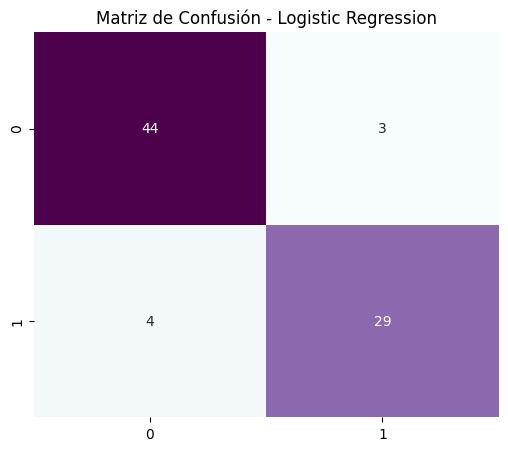

In [ ]:
#. Matriz de confusión.
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_log,
    cbar = False,
    annot = True,
    fmt = 'd',
    cmap = 'BuPu'
)

plt.title('Matriz de Confusión - Logistic Regression')

plt.show()

In [ ]:
#. Coeficientes.
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': log_model.coef_[0]
})

coef_df

,Variable,Coeficiente
0,CompPrice,1.859358
1,Income,0.599948
2,Advertising,1.403047
3,Population,-0.058587
4,Price,-2.824159
5,Age,-0.970026
6,Education,-0.076315
7,ShelveLoc_Good,2.237737
8,ShelveLoc_Medium,1.176577
9,Urban_Yes,-0.195723


### **Optimización del modelo.**

In [ ]:
#. Parámetros a evaluar.
log_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

log_params

{'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear'], 'penalty': ['l2']}

In [ ]:
#. Configuración de GridSearch.
log_grid = GridSearchCV(
    estimator = LogisticRegression(
        max_iter = 1000,
        random_state = 42
    ),
    param_grid = log_params,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)

In [ ]:
#. Entrenamiento.
log_grid.fit(
    X_train_scaled,
    y_train
)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='accuracy')

In [ ]:
#. Mejores parámetros encontrados.
print("Mejores parámetros encontrados:")
print(log_grid.best_params_)

#. Mejor accuracy.
print(f'\nMejor accuracy: {log_grid.best_score_:.2f}')

Mejores parámetros encontrados:
{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}

Mejor accuracy: 0.88


In [ ]:
#. Mejor modelo.
best_log_model = log_grid.best_estimator_

#. Predicciones.
y_pred_best_log = best_log_model.predict(
    X_test_scaled
)

#. Accuracy final.
best_log_accuracy = accuracy_score(
    y_test,
    y_pred_best_log
)

print(f'Accuracy optimizado: {best_log_accuracy:.2f}')

Accuracy optimizado: 0.91


In [ ]:
print(
    classification_report(
        y_test,
        y_pred_best_log
    )
)

              precision    recall  f1-score   support

           0       0.93      0.91      0.92        47
           1       0.88      0.91      0.90        33

    accuracy                           0.91        80
   macro avg       0.91      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80



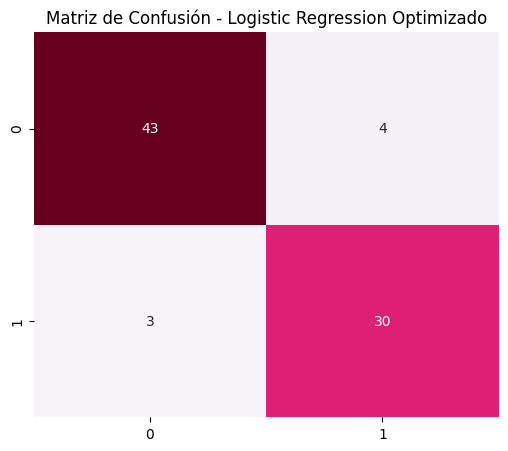

In [ ]:
cm_best_log = confusion_matrix(y_test, y_pred_best_log)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_best_log,
    cbar = False,
    annot = True,
    fmt = 'd',
    cmap = 'PuRd'
)

plt.title('Matriz de Confusión - Logistic Regression Optimizado')


plt.show()

In [ ]:
#. Coeficientes.
best_coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': best_log_model.coef_[0]
})

best_coef_df

,Variable,Coeficiente
0,CompPrice,2.520254
1,Income,0.786232
2,Advertising,1.874320
3,Population,-0.088321
4,Price,-3.757801
5,Age,-1.241777
6,Education,-0.093261
7,ShelveLoc_Good,2.973818
8,ShelveLoc_Medium,1.629342
9,Urban_Yes,-0.266987


# **Análisis de los modelos.**

In [ ]:
#. Creación de DataFrame comparativo.
models_comparison = pd.DataFrame({
    'Modelo': [
        'Decision Tree',
        'Logistic Regression'
    ],

    'Accuracy': [
        best_tree_accuracy,
        best_log_accuracy
    ]
})

#. Ordenar resultados.
models_comparison = models_comparison.sort_values(
    by = 'Accuracy',
    ascending = False
)

models_comparison

,Modelo,Accuracy
1,Logistic Regression,0.9125
0,Decision Tree,0.7750


In [ ]:
print("Decision Tree.")
print(
    classification_report(
        y_test,
        y_pred_best_tree
    )
)

print("Logistic Regression.")
print(
    classification_report(
        y_test,
        y_pred_best_log
    )
)

Decision Tree.
              precision    recall  f1-score   support

           0       0.78      0.85      0.82        47
           1       0.76      0.67      0.71        33

    accuracy                           0.78        80
   macro avg       0.77      0.76      0.76        80
weighted avg       0.77      0.78      0.77        80

Logistic Regression.
              precision    recall  f1-score   support

           0       0.93      0.91      0.92        47
           1       0.88      0.91      0.90        33

    accuracy                           0.91        80
   macro avg       0.91      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80



In [ ]:
#. Recall de clase peligrosa.
recall_comparison = pd.DataFrame({
    'Modelo': [
        'Decision Tree',
        'Logistic Regression'
    ],

    'Recall_Clase_1': [

        classification_report(
            y_test,
            y_pred_best_tree,
            output_dict = True
        )['1']['recall'],

        classification_report(
            y_test,
            y_pred_best_log,
            output_dict = True
        )['1']['recall']
    ]
})

#. Ordenar resultados.
recall_comparison = recall_comparison.sort_values(
    by = 'Recall_Clase_1',
    ascending = False
)

recall_comparison

,Modelo,Recall_Clase_1
1,Logistic Regression,0.909091
0,Decision Tree,0.666667


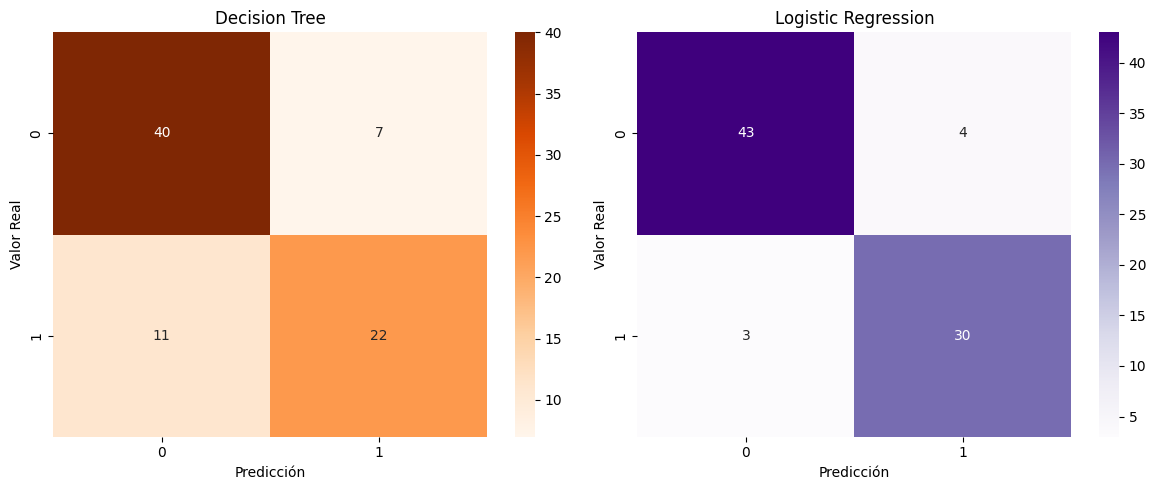

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

#. Decision Tree.
sns.heatmap(
    confusion_matrix(y_test, y_pred_best_tree),
    annot=True,
    fmt='d',
    cmap='Oranges',
    ax=axes[0]
)

axes[0].set_title('Decision Tree')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor Real')

#. Logistic Regression.
sns.heatmap(
    confusion_matrix(y_test, y_pred_best_log),
    annot=True,
    fmt='d',
    cmap='Purples',
    ax=axes[1]
)

axes[1].set_title('Logistic Regression')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

In [ ]:
#. Mejor modelo por accuracy.
best_model_accuracy = models_comparison.iloc[0]

print("Mejor modelo según Accuracy:\n")

print(f"Modelo: {best_model_accuracy['Modelo']}")
print(f"Accuracy: {best_model_accuracy['Accuracy']:.4f}")

Mejor modelo según Accuracy:

Modelo: Logistic Regression
Accuracy: 0.9125


# **Conclusión.**

En conclusión, el proyecto permitió aplicar de manera práctica las distintas etapas de un flujo de ciencia de datos, desde la adquisición y transformación de datos hasta la evaluación de modelos predictivos. Los resultados obtenidos demuestran que es posible predecir de forma satisfactoria si una sucursal alcanzará ventas altas o bajas utilizando las variables disponibles, siendo la **Logistic Regression** la alternativa más adecuada para este conjunto de datos debido a su mejor capacidad de generalización y desempeño global.


# **DataFrame final.**

In [ ]:
df_mod.to_csv("carseats_processed.csv", index=False)